In [1]:
######Done
import os
import random
import numpy as np
import torch

SEED = 42

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# Torch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.environ["PYTHONHASHSEED"] = str(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


In [2]:
#### Device Done
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
####Done
import rdkit
from rdkit import Chem
print("RDKit working")
import torch_geometric
print("PyG working")

RDKit working
PyG working


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("masterlist.csv")

# Replace infinity values
df = df.replace([np.inf, -np.inf], np.nan)

C:\Users\RENUKA SURESH\AppData\Local\Temp\ipykernel_13784\3758224468.py:4: DtypeWarning: Columns (0,1,667,1415) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("masterlist.csv")


In [5]:
print(df[['Herbicide','Fungicide','Insecticide','Microbicide']].sum())

Herbicide      334.0
Fungicide      588.0
Insecticide    603.0
Microbicide    416.0
dtype: float64


In [6]:
# Remove rows with missing SMILES
df = df.dropna(subset=['Smile'])

# Remove rows where SMILES is empty string
df = df[df['Smile'].astype(str).str.strip() != ""]

# Remove rows with missing labels
df = df.dropna(subset=['Herbicide','Fungicide','Insecticide','Microbicide'])

print(df.shape)


(2318, 1450)


In [7]:
# Remove duplicate SMILES
df = df.drop_duplicates(subset='Smile').reset_index(drop=True)

print("Shape after deduplication:", df.shape)


Shape after deduplication: (2301, 1450)


In [8]:
print(df[['Herbicide','Fungicide','Insecticide','Microbicide']].sum())


Herbicide      334.0
Fungicide      588.0
Insecticide    603.0
Microbicide    416.0
dtype: float64


In [9]:
df.to_csv("master_clean_deduplicated.csv", index=False)
print("File saved successfully.")
df = pd.read_csv("master_clean_deduplicated.csv")

File saved successfully.


C:\Users\RENUKA SURESH\AppData\Local\Temp\ipykernel_13784\3039419517.py:3: DtypeWarning: Columns (667,1415) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("master_clean_deduplicated.csv")


In [10]:
#Check smile validity
from rdkit import Chem

def is_valid_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return mol is not None
    except:
        return False

df['valid_smiles'] = df['Smile'].apply(is_valid_smiles)

print("Valid:", df['valid_smiles'].sum())
print("Invalid:", len(df) - df['valid_smiles'].sum())


Valid: 2294
Invalid: 7


In [11]:
df = df[df['valid_smiles'] == True].drop(columns=['valid_smiles']).reset_index(drop=True)

print("Final clean dataset shape:", df.shape)

Final clean dataset shape: (2294, 1450)


In [12]:
#Save file
df.to_csv("master_final_clean.csv", index=False)

print("Final clean dataset saved successfully.")


Final clean dataset saved successfully.


In [13]:
#### Extract class-specific SMILES (DO NOT SHUFFLE)

herb_smiles = df[df["Herbicide"] == 1]["Smile"].tolist()
fungi_smiles = df[df["Fungicide"] == 1]["Smile"].tolist()
insect_smiles = df[df["Insecticide"] == 1]["Smile"].tolist()
micro_smiles = df[df["Microbicide"] == 1]["Smile"].tolist()

print("Herbicide:", len(herb_smiles))
print("Fungicide:", len(fungi_smiles))
print("Insecticide:", len(insect_smiles))
print("Microbicide:", len(micro_smiles))

Herbicide: 334
Fungicide: 588
Insecticide: 596
Microbicide: 416


In [16]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Split temp into validation and test (15% each)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (1605, 1450)
Validation: (344, 1450)
Test: (345, 1450)


In [19]:
# Save the reproducible splits

train_df.to_csv("train_original.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("\nSplit files saved successfully:")
print("train_original.csv")
print("val.csv")
print("test.csv")

# Verify class distribution

print("\nClass distribution:")

for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print("Herbicide:", int(data["Herbicide"].sum()))
    print("Fungicide:", int(data["Fungicide"].sum()))
    print("Insecticide:", int(data["Insecticide"].sum()))
    print("Microbicide:", int(data["Microbicide"].sum()))


Split files saved successfully:
train_original.csv
val.csv
test.csv

Class distribution:

Train
Herbicide: 231
Fungicide: 411
Insecticide: 424
Microbicide: 297

Validation
Herbicide: 58
Fungicide: 89
Insecticide: 86
Microbicide: 63

Test
Herbicide: 45
Fungicide: 88
Insecticide: 86
Microbicide: 56


In [17]:
# Check the newly generated split BEFORE loading the old files

print("Newly generated split:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nClass distribution")

for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print("Herbicide:", data["Herbicide"].sum())
    print("Fungicide:", data["Fungicide"].sum())
    print("Insecticide:", data["Insecticide"].sum())
    print("Microbicide:", data["Microbicide"].sum())

Newly generated split:
Train: (1605, 1450)
Validation: (344, 1450)
Test: (345, 1450)

Class distribution

Train
Herbicide: 231.0
Fungicide: 411.0
Insecticide: 424.0
Microbicide: 297.0

Validation
Herbicide: 58.0
Fungicide: 89.0
Insecticide: 86.0
Microbicide: 63.0

Test
Herbicide: 45.0
Fungicide: 88.0
Insecticide: 86.0
Microbicide: 56.0


In [20]:
train_decoys = train_df[
    (train_df['Herbicide'] == 0) &
    (train_df['Fungicide'] == 0) &
    (train_df['Insecticide'] == 0) &
    (train_df['Microbicide'] == 0)
]

print("Train decoys:", len(train_decoys))


Train decoys: 475


In [21]:
### Combine all herbicide SMILES into one string
all_smiles_text = "".join(herb_smiles)

# Unique characters
vocab = sorted(list(set(all_smiles_text)))

print("Vocabulary size:", len(vocab))
print("Characters:", vocab)


Vocabulary size: 30
Characters: ['#', '(', ')', '+', '-', '.', '/', '1', '2', '3', '4', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'a', 'l', 'r', 's']


In [22]:
#### Add special tokens
START_TOKEN = "<"
END_TOKEN = ">"
PAD_TOKEN = "_"

vocab = [PAD_TOKEN, START_TOKEN, END_TOKEN] + vocab

vocab_size = len(vocab)

print("New vocab size:", vocab_size)
print(vocab)


New vocab size: 33
['_', '<', '>', '#', '(', ')', '+', '-', '.', '/', '1', '2', '3', '4', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'a', 'l', 'r', 's']


In [23]:
#### =========================
# =========================
# REBUILD TOKEN MAPPING
# =========================

char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

print("Token indices:")
print("_  ->", char_to_idx["_"])
print("<  ->", char_to_idx["<"])
print(">  ->", char_to_idx[">"])
print("#  ->", char_to_idx["#"])

Token indices:
_  -> 0
<  -> 1
>  -> 2
#  -> 3


In [24]:
####
# =========================
# ADD START & END TOKENS
# =========================

smiles_with_tokens = [START_TOKEN + smi + END_TOKEN for smi in herb_smiles]

# Compute maximum sequence length
max_len = max(len(smi) for smi in smiles_with_tokens)

print("Max sequence length:", max_len)
print("Example tokenized SMILES:", smiles_with_tokens[0])

Max sequence length: 88
Example tokenized SMILES: <OC(=O)COC1=C(Cl)C=C(Cl)C(Cl)=C1>


In [25]:
#### =========================
# ENCODE + PAD SEQUENCES
# =========================

import numpy as np

encoded_smiles = []

for smi in smiles_with_tokens:
    # Convert characters to indices
    encoded = [char_to_idx[char] for char in smi]
    
    # Pad sequence to max_len
    padded = encoded + [char_to_idx[PAD_TOKEN]] * (max_len - len(encoded))
    
    encoded_smiles.append(padded)

encoded_smiles = np.array(encoded_smiles)

print("Encoded shape:", encoded_smiles.shape)
print("First encoded sequence (first 15 tokens):")
print(encoded_smiles[0][:15])

Encoded shape: (334, 88)
First encoded sequence (first 15 tokens):
[ 1 23 18  4 14 23  5 18 23 18 10 14 18  4 18]


In [26]:
####
# Convert to torch tensor
data = torch.tensor(encoded_smiles, dtype=torch.long)

# Inputs: everything except last token
inputs = data[:, :-1]

# Targets: everything except first token
targets = data[:, 1:]

print("Input shape:", inputs.shape)
print("Target shape:", targets.shape)


Input shape: torch.Size([334, 87])
Target shape: torch.Size([334, 87])


In [27]:
####
import torch.nn as nn

class SmilesGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=256, num_layers=2):
        super(SmilesGenerator, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out


# Initialize model
model = SmilesGenerator(vocab_size)
print(model)

# Move to device (already defined in seed cell)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=char_to_idx[PAD_TOKEN])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model, loss, optimizer ready.")

SmilesGenerator(
  (embedding): Embedding(33, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True)
  (fc): Linear(in_features=256, out_features=33, bias=True)
)
Model, loss, optimizer ready.


In [28]:
####
# =========================
# HERBICIDE TRAINING (FIXED)
# =========================

epochs = 200  # total training epochs

model.train()

loss_history = []

for epoch in range(epochs):
    inputs_batch = inputs.to(device)
    targets_batch = targets.to(device)

    optimizer.zero_grad()
    
    outputs = model(inputs_batch)
    
    loss = criterion(
        outputs.reshape(-1, vocab_size),
        targets_batch.reshape(-1)
    )
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Save loss log
import pandas as pd
pd.DataFrame({"epoch": range(1, epochs+1),
              "loss": loss_history}).to_csv("herb_training_log.csv", index=False)

print("Herbicide training complete.")

Epoch [25/200], Loss: 2.2025
Epoch [50/200], Loss: 1.8247
Epoch [75/200], Loss: 1.4051
Epoch [100/200], Loss: 1.1349
Epoch [125/200], Loss: 0.9722
Epoch [150/200], Loss: 0.8544
Epoch [175/200], Loss: 0.7570
Epoch [200/200], Loss: 0.6840
Herbicide training complete.


In [29]:
#### =========================
# SAVE HERBICIDE MODEL
# =========================

torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,
    'char_to_idx': char_to_idx,
    'idx_to_char': idx_to_char,
    'max_len': max_len
}, "herb_lstm_checkpoint.pt")

print("Herbicide model saved.")

Herbicide model saved.


In [30]:
##### =========================
# LOAD SAVED HERB MODEL
# =========================

checkpoint = torch.load("herb_lstm_checkpoint.pt", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])

vocab = checkpoint['vocab']
char_to_idx = checkpoint['char_to_idx']
idx_to_char = checkpoint['idx_to_char']
max_len = checkpoint['max_len']

model.eval()

print("Herbicide model loaded for generation.")

Herbicide model loaded for generation.


In [31]:
#### =========================
# FIX SEED BEFORE GENERATION
# =========================

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [32]:
####
import torch.nn.functional as F

def generate_smiles(model, max_len=88, temperature=1.0):
    model.eval()
    
    generated = [char_to_idx[START_TOKEN]]
    
    for _ in range(max_len):
        input_tensor = torch.tensor([generated], dtype=torch.long).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
        
        logits = output[0, -1] / temperature
        probs = F.softmax(logits, dim=0)
        
        next_token = torch.multinomial(probs, 1).item()
        
        if idx_to_char[next_token] == END_TOKEN:
            break
        
        generated.append(next_token)
    
    smiles = "".join([idx_to_char[idx] for idx in generated[1:]])
    return smiles

# =========================
# FIXED GENERATION BLOCK
# =========================

# Reset seeds BEFORE generation
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

generated_smiles = []

for _ in range(10):
    smi = generate_smiles(model)
    generated_smiles.append(smi)
    print(smi)

print("Generation complete.")

CON=C1(NS(=O)(=N)C1=C(Cl)C=CC=C2)=N1
CCOC1=CC=NN1C1=NC=C(Cl)N1C(=O)C1=C(C=C2N=C1C)NC1=NC(C)=CC(OC2=C(C)C=C(OC2=NC(C=O)C(O)C(F
[Na+].C(O)1=NNC([SA-])=NC(Cl)=O
COC1=CC(C(=O)NC(OC2=CC=C(F)S=N1)C(=O)N1C(F)(F)F
CCN(C)C(=O)N1C(=O)C1=C(Cl)C=CC(=C2)C(=O)C1=NC(Cl)CCC
NCC(=O)C1=C(Cl)C=CS2N(=C1
CCNC(C)C(=O)N[C1HO)=N(N1SC(=O)CCC(C()C)C(C)(C)C#C
CCON(CCC2CCS(S)(=O)=CCOC1=NC=CC(OC2=C(Cl)C=C(Cl)C=C2)C=C2)=C1C1=CC=C2Cl
CNC(=O)C1=C(C(=C(CC)C=C2)C1=O
OC1=CC=CC(OC2=C(OC3=C(C)C=CC=C1)O2)C=C(Cl)C=C1
Generation complete.


In [33]:
##### =========================
# GENERATE FULL HERB SET
# =========================

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

num_generate = 3000
generated_smiles = []

for _ in range(num_generate):
    smi = generate_smiles(model)
    generated_smiles.append(smi)

print("Total generated:", len(generated_smiles))

Total generated: 3000


In [34]:
# =========================
# RDKit FILTERING
# =========================

from rdkit import Chem

valid_smiles = []

for smi in generated_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical = Chem.MolToSmiles(mol, canonical=True)
        valid_smiles.append(canonical)

print("Valid SMILES:", len(valid_smiles))


# Remove duplicates (deterministic)
valid_smiles = sorted(list(set(valid_smiles)))

print("Unique valid SMILES:", len(valid_smiles))


# Remove molecules already present in real herb dataset
real_set = set(herb_smiles)

new_generated = sorted([smi for smi in valid_smiles if smi not in real_set])

print("After removing real ones:", len(new_generated))

Valid SMILES: 339
Unique valid SMILES: 339
After removing real ones: 339


In [35]:
#### Real herb in TRAIN only
train_herb_smiles = train_df[train_df["Herbicide"] == 1]["Smile"].tolist()

# Remove overlap with TRAIN only (not full dataset)
train_real_set = set(train_herb_smiles)

herb_new_filtered = sorted([s for s in new_generated if s not in train_real_set])

print("Available novel herb (vs TRAIN):", len(herb_new_filtered))

needed_herb = 475 - len(train_herb_smiles)

synthetic_herb = herb_new_filtered[:needed_herb]

print("Synthetic selected:", len(synthetic_herb))
print("Final herb total (train):", len(train_herb_smiles) + len(synthetic_herb))

Available novel herb (vs TRAIN): 339
Synthetic selected: 244
Final herb total (train): 475


In [44]:
# =========================
# SAVE HERB RAW GENERATION
# =========================

pd.DataFrame({
    "generated_smiles": generated_smiles
}).to_csv("herb_generated_raw_3000_rerun.csv", index=False)

print("Saved raw 3000 herb SMILES.")


# =========================
# SAVE HERB VALID FILTERED
# =========================

pd.DataFrame({
    "valid_smiles": new_generated
}).to_csv("herb_valid_filtered_339_rerun.csv", index=False)

print("Saved filtered valid herb SMILES.")


# =========================
# SAVE FINAL SELECTED HERB SYNTHETIC
# =========================

synthetic_herb_df = pd.DataFrame({
    "Name": [f"SYN_HERB_{i}" for i in range(len(synthetic_herb))],
    "Smile": synthetic_herb,
    "Herbicide": 1,
    "Fungicide": 0,
    "Insecticide": 0,
    "Microbicide": 0
})

synthetic_herb_df.to_csv(
    "synthetic_herb_train_rerun.csv",
    index=False
)

print("Saved rerun herbicide files.")
print("Shape:", synthetic_herb_df.shape)

Saved raw 3000 herb SMILES.
Saved filtered valid herb SMILES.
Saved rerun herbicide files.
Shape: (244, 6)


# =========================
# SAVE HERB RAW GENERATION
# =========================

pd.DataFrame({
    "generated_smiles": generated_smiles
}).to_csv("herb_generated_raw_3000.csv", index=False)

print("Saved raw 3000 herb SMILES.")


# =========================
# SAVE HERB VALID FILTERED
# =========================

pd.DataFrame({
    "valid_smiles": new_generated
}).to_csv("herb_valid_filtered_339.csv", index=False)

print("Saved filtered valid herb SMILES.")

# =========================
# SAVE FINAL SELECTED HERB SYNTHETIC (244)
# =========================

synthetic_herb_df = pd.DataFrame({
    "Name": [f"SYN_HERB_{i}" for i in range(len(synthetic_herb))],
    "Smile": synthetic_herb,
    "Herbicide": 1,
    "Fungicide": 0,
    "Insecticide": 0,
    "Microbicide": 0
})

synthetic_herb_df.to_csv("synthetic_herb_train.csv", index=False)

print("Saved synthetic_herb_train.csv")
print("Shape:", synthetic_herb_df.shape)

**Fungicide**

In [45]:
# =========================
# TRAIN FUNGICIDE SMILES
# =========================

fungi_train_smiles = train_df[train_df["Fungicide"] == 1]["Smile"].tolist()

print("Train Fungicide count:", len(fungi_train_smiles))
print(fungi_train_smiles[:5])

Train Fungicide count: 411
['CC1=C(C(=CC=C1)C)N(C2CCOC2=O)C(=O)CCl', 'CCCCCCCCCCCCOS(=O)(=O)[O-].[Na+]', 'CCCCC1=C(N=C(NC1=O)NCC)C', 'CN1C(=CC(=N1)C2=CC=C(C=C2)Cl)OCC3=CC=CC=C3C(=COC)C(=O)OC', 'CC(=O)[O-].CC(=O)[O-].[NH4+].[Cu+]']


In [46]:
# =========================
# FUNGICIDE VOCABULARY
# =========================

all_smiles_text_fungi = "".join(fungi_train_smiles)

vocab_fungi = sorted(list(set(all_smiles_text_fungi)))

print("Base vocab size (fungi):", len(vocab_fungi))
print(vocab_fungi)

Base vocab size (fungi): 36
['#', '(', ')', '+', '-', '.', '1', '2', '3', '4', '=', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'M', 'N', 'O', 'P', 'S', 'Z', '[', ']', 'a', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's', 'u']


In [47]:
# Add special tokens
START_TOKEN = "<"
END_TOKEN = ">"
PAD_TOKEN = "_"

vocab_fungi = [PAD_TOKEN, START_TOKEN, END_TOKEN] + vocab_fungi

vocab_size_fungi = len(vocab_fungi)

print("Final vocab size (fungi):", vocab_size_fungi)
print(vocab_fungi[:6])

Final vocab size (fungi): 39
['_', '<', '>', '#', '(', ')']


In [48]:
# =========================
# FUNGICIDE TOKEN MAPPING
# =========================

char_to_idx_fungi = {ch: i for i, ch in enumerate(vocab_fungi)}
idx_to_char_fungi = {i: ch for ch, i in char_to_idx_fungi.items()}

print("_ ->", char_to_idx_fungi["_"])
print("< ->", char_to_idx_fungi["<"])
print("> ->", char_to_idx_fungi[">"])

_ -> 0
< -> 1
> -> 2


In [49]:
# =========================
# FUNGICIDE TOKENIZED SEQUENCES
# =========================

smiles_with_tokens_fungi = [
    START_TOKEN + smi + END_TOKEN
    for smi in fungi_train_smiles
]

max_len_fungi = max(len(smi) for smi in smiles_with_tokens_fungi)

print("Max sequence length (fungi):", max_len_fungi)
print("Example:", smiles_with_tokens_fungi[0])

Max sequence length (fungi): 158
Example: <CC1=C(C(=CC=C1)C)N(C2CCOC2=O)C(=O)CCl>


In [50]:
# =========================
# ENCODE + PAD (FUNGICIDE)
# =========================

import numpy as np

encoded_fungi = []

for smi in smiles_with_tokens_fungi:
    encoded = [char_to_idx_fungi[ch] for ch in smi]
    padded = encoded + [char_to_idx_fungi[PAD_TOKEN]] * (max_len_fungi - len(encoded))
    encoded_fungi.append(padded)

encoded_fungi = np.array(encoded_fungi)

print("Encoded fungi shape:", encoded_fungi.shape)
print("First 10 tokens of first sequence:", encoded_fungi[0][:10])

Encoded fungi shape: (411, 158)
First 10 tokens of first sequence: [ 1 16 16  9 13 16  4 16  4 13]


In [51]:
# =========================
# TENSOR CONVERSION (FUNGICIDE)
# =========================

import torch

data_fungi = torch.tensor(encoded_fungi, dtype=torch.long)

inputs_fungi = data_fungi[:, :-1]
targets_fungi = data_fungi[:, 1:]

print("Inputs shape:", inputs_fungi.shape)
print("Targets shape:", targets_fungi.shape)

Inputs shape: torch.Size([411, 157])
Targets shape: torch.Size([411, 157])


In [52]:
# =========================
# FUNGICIDE MODEL
# =========================

import torch.nn as nn

class SmilesGeneratorFungi(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=256, num_layers=2):
        super(SmilesGeneratorFungi, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out


model_fungi = SmilesGeneratorFungi(vocab_size_fungi)
model_fungi = model_fungi.to(device)

criterion_fungi = nn.CrossEntropyLoss(ignore_index=char_to_idx_fungi[PAD_TOKEN])
optimizer_fungi = torch.optim.Adam(model_fungi.parameters(), lr=0.001)

print("Fungicide model ready.")

Fungicide model ready.


In [53]:
# =========================
# FUNGICIDE TRAINING
# =========================

epochs = 200

model_fungi.train()

loss_history_fungi = []

for epoch in range(epochs):
    inputs_batch = inputs_fungi.to(device)
    targets_batch = targets_fungi.to(device)

    optimizer_fungi.zero_grad()
    
    outputs = model_fungi(inputs_batch)
    
    loss = criterion_fungi(
        outputs.reshape(-1, vocab_size_fungi),
        targets_batch.reshape(-1)
    )
    
    loss.backward()
    optimizer_fungi.step()
    
    loss_history_fungi.append(loss.item())
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Save loss log
import pandas as pd
pd.DataFrame({
    "epoch": range(1, epochs+1),
    "loss": loss_history_fungi
}).to_csv("fungi_training_log.csv", index=False)

print("Fungicide training complete.")

Epoch [25/200], Loss: 2.2423
Epoch [50/200], Loss: 1.8356
Epoch [75/200], Loss: 1.4092
Epoch [100/200], Loss: 1.1254
Epoch [125/200], Loss: 0.9730
Epoch [150/200], Loss: 0.8277
Epoch [175/200], Loss: 0.7123
Epoch [200/200], Loss: 0.6243
Fungicide training complete.


In [54]:
# =========================
# SAVE FUNGICIDE MODEL
# =========================

torch.save({
    'model_state_dict': model_fungi.state_dict(),
    'vocab': vocab_fungi,
    'char_to_idx': char_to_idx_fungi,
    'idx_to_char': idx_to_char_fungi,
    'max_len': max_len_fungi
}, "fungi_lstm_checkpoint.pt")

print("Fungicide model saved.")

Fungicide model saved.


In [55]:
import torch.nn.functional as F

def generate_smiles_fungi(model, max_len=max_len_fungi, temperature=1.0):
    model.eval()
    
    generated = [char_to_idx_fungi[START_TOKEN]]
    
    for _ in range(max_len):
        input_tensor = torch.tensor([generated], dtype=torch.long).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
        
        logits = output[0, -1] / temperature
        probs = F.softmax(logits, dim=0)
        
        next_token = torch.multinomial(probs, 1).item()
        
        if idx_to_char_fungi[next_token] == END_TOKEN:
            break
        
        generated.append(next_token)
    
    smiles = "".join([idx_to_char_fungi[idx] for idx in generated[1:]])
    return smiles

print("Fungicide generation function ready.")

Fungicide generation function ready.


In [56]:
# =========================
# GENERATE 3000 FUNGICIDE
# =========================

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

num_generate = 3000
generated_fungi = []

for _ in range(num_generate):
    smi = generate_smiles_fungi(model_fungi)
    generated_fungi.append(smi)

print("Total generated fungi:", len(generated_fungi))

Total generated fungi: 3000


In [57]:
# =========================
# SAVE RAW 3000 FUNGICIDE
# =========================

pd.DataFrame({
    "generated_smiles": generated_fungi
}).to_csv("fungi_generated_raw_3000.csv", index=False)

print("Saved fungi_generated_raw_3000.csv")

Saved fungi_generated_raw_3000.csv


In [58]:
# =========================
# RDKit FILTERING (FUNGICIDE)
# =========================

from rdkit import Chem

valid_fungi = []

for smi in generated_fungi:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical = Chem.MolToSmiles(mol, canonical=True)
        valid_fungi.append(canonical)

print("Valid fungi SMILES:", len(valid_fungi))

# Remove duplicates
valid_fungi = sorted(list(set(valid_fungi)))

print("Unique valid fungi SMILES:", len(valid_fungi))

Valid fungi SMILES: 806
Unique valid fungi SMILES: 727


In [59]:
# =========================
# REMOVE TRAIN OVERLAP (FUNGICIDE)
# =========================

train_fungi_smiles = set(fungi_train_smiles)

fungi_new_filtered = sorted([s for s in valid_fungi if s not in train_fungi_smiles])

print("Novel valid fungi (vs TRAIN):", len(fungi_new_filtered))

Novel valid fungi (vs TRAIN): 720


In [60]:
# =========================
# SELECT REQUIRED 64 FUNGICIDE
# =========================

needed_fungi = 475 - len(fungi_train_smiles)

synthetic_fungi = fungi_new_filtered[:needed_fungi]

print("Required fungi:", needed_fungi)
print("Selected fungi:", len(synthetic_fungi))
print("Final fungi total (train):", len(fungi_train_smiles) + len(synthetic_fungi))

Required fungi: 64
Selected fungi: 64
Final fungi total (train): 475


In [63]:
# =========================
# SAVE FILTERED VALID FUNGICIDE
# =========================

pd.DataFrame({
    "valid_smiles": fungi_new_filtered
}).to_csv("fungi_valid_filtered_720.csv", index=False)

print("Saved fungi_valid_filtered_720.csv")

# =========================
# SAVE FINAL FUNGICIDE SYNTHETIC (64)
# =========================

synthetic_fungi_df = pd.DataFrame({
    "Name": [f"SYN_FUNGI_{i}" for i in range(len(synthetic_fungi))],
    "Smile": synthetic_fungi,
    "Herbicide": 0,
    "Fungicide": 1,
    "Insecticide": 0,
    "Microbicide": 0
})

synthetic_fungi_df.to_csv("synthetic_fungi_train_rerun.csv", index=False)

print("Saved synthetic_fungi_train_rerun.csv")
print("Shape:", synthetic_fungi_df.shape)

Saved fungi_valid_filtered_720.csv
Saved synthetic_fungi_train_rerun.csv
Shape: (64, 6)


**Insecticide**

In [65]:
import pandas as pd
import numpy as np
import torch
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

train_df = pd.read_csv("train_original.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nLabel distribution (TRAIN):")
print("Herbicide:", train_df["Herbicide"].sum())
print("Fungicide:", train_df["Fungicide"].sum())
print("Insecticide:", train_df["Insecticide"].sum())
print("Microbicide:", train_df["Microbicide"].sum())

C:\Users\RENUKA SURESH\AppData\Local\Temp\ipykernel_13784\3181661332.py:14: DtypeWarning: Columns (667,1415) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train_original.csv")


Train: (1605, 1450)
Validation: (344, 1450)
Test: (345, 1450)

Label distribution (TRAIN):
Herbicide: 231.0
Fungicide: 411.0
Insecticide: 424.0
Microbicide: 297.0


In [66]:
# =========================
# TRAIN INSECTICIDE SMILES
# =========================

insect_train_smiles = train_df[train_df["Insecticide"] == 1]["Smile"].tolist()

print("Train Insecticide count:", len(insect_train_smiles))
print(insect_train_smiles[:5])

Train Insecticide count: 424
['CC(=NC#N)N(C)CC1=CN=C(C=C1)Cl', '[S-2].[S-2].[S-2].[As+3].[As+3]', 'C1CSC(=NC#N)N1CC2=CN=C(C=C2)Cl', 'CCCCCCCCCCCCOS(=O)(=O)[O-].[Na+]', 'C1=CC(=CC=C1CSC2=CC=C(C=C2)F)Cl']


In [67]:
# =========================
# INSECTICIDE VOCABULARY
# =========================

all_smiles_text_insect = "".join(insect_train_smiles)

vocab_insect = sorted(list(set(all_smiles_text_insect)))

print("Base vocab size (insect):", len(vocab_insect))
print(vocab_insect)

Base vocab size (insect): 39
['#', '(', ')', '+', '-', '.', '1', '2', '3', '4', '5', '6', '7', '=', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'M', 'N', 'O', 'P', 'S', 'Z', '[', ']', 'a', 'b', 'g', 'i', 'l', 'n', 'o', 'r', 's', 'u']


In [68]:
# Add special tokens
START_TOKEN = "<"
END_TOKEN = ">"
PAD_TOKEN = "_"

vocab_insect = [PAD_TOKEN, START_TOKEN, END_TOKEN] + vocab_insect

vocab_size_insect = len(vocab_insect)

print("Final vocab size (insect):", vocab_size_insect)
print("First 6 tokens:", vocab_insect[:6])

Final vocab size (insect): 42
First 6 tokens: ['_', '<', '>', '#', '(', ')']


In [69]:
# =========================
# INSECTICIDE TOKEN MAPPING
# =========================

char_to_idx_insect = {ch: i for i, ch in enumerate(vocab_insect)}
idx_to_char_insect = {i: ch for ch, i in char_to_idx_insect.items()}

print("_ ->", char_to_idx_insect["_"])
print("< ->", char_to_idx_insect["<"])
print("> ->", char_to_idx_insect[">"])

_ -> 0
< -> 1
> -> 2


In [71]:
# =========================
# TOKENIZED INSECTICIDE SEQUENCES
# =========================

smiles_with_tokens_insect = [
    START_TOKEN + smi + END_TOKEN
    for smi in insect_train_smiles
]

max_len_insect = max(len(smi) for smi in smiles_with_tokens_insect)

print("Max sequence length (insect):", max_len_insect)
print("Example:", smiles_with_tokens_insect[0])

Max sequence length (insect): 232
Example: <CC(=NC#N)N(C)CC1=CN=C(C=C1)Cl>


In [72]:
# =========================
# ENCODE + PAD (INSECTICIDE)
# =========================

import numpy as np

encoded_insect = []

for smi in smiles_with_tokens_insect:
    encoded = [char_to_idx_insect[ch] for ch in smi]
    padded = encoded + [char_to_idx_insect[PAD_TOKEN]] * (max_len_insect - len(encoded))
    encoded_insect.append(padded)

encoded_insect = np.array(encoded_insect)

print("Encoded insect shape:", encoded_insect.shape)
print("First 10 tokens:", encoded_insect[0][:10])

Encoded insect shape: (424, 232)
First 10 tokens: [ 1 19 19  4 16 25 19  3 25  5]


In [73]:
# =========================
# TENSOR CONVERSION (INSECTICIDE)
# =========================

import torch

data_insect = torch.tensor(encoded_insect, dtype=torch.long)

inputs_insect = data_insect[:, :-1]
targets_insect = data_insect[:, 1:]

print("Inputs shape:", inputs_insect.shape)
print("Targets shape:", targets_insect.shape)

Inputs shape: torch.Size([424, 231])
Targets shape: torch.Size([424, 231])


In [76]:
print("Torch seed check before insect model:")
print(torch.initial_seed())

Torch seed check before insect model:
42


In [77]:
# =========================
# INSECTICIDE MODEL
# =========================

import torch.nn as nn

class SmilesGeneratorInsect(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=256, num_layers=2):
        super(SmilesGeneratorInsect, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out


model_insect = SmilesGeneratorInsect(vocab_size_insect)
model_insect = model_insect.to(device)

criterion_insect = nn.CrossEntropyLoss(ignore_index=char_to_idx_insect[PAD_TOKEN])
optimizer_insect = torch.optim.Adam(model_insect.parameters(), lr=0.001)

print("Insecticide model ready.")

Insecticide model ready.


In [78]:
print("Torch seed after insect model:")
print(torch.initial_seed())

Torch seed after insect model:
42


In [83]:
# =========================
# INSECTICIDE TRAINING
# =========================

epochs = 200

model_insect.train()

loss_history_insect = []

for epoch in range(epochs):
    inputs_batch = inputs_insect.to(device)
    targets_batch = targets_insect.to(device)

    optimizer_insect.zero_grad()
    
    outputs = model_insect(inputs_batch)
    
    loss = criterion_insect(
        outputs.reshape(-1, vocab_size_insect),
        targets_batch.reshape(-1)
    )
    
    loss.backward()
    optimizer_insect.step()
    
    loss_history_insect.append(loss.item())
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Save loss log
import pandas as pd
pd.DataFrame({
    "epoch": range(1, epochs+1),
    "loss": loss_history_insect
}).to_csv("insect_training_log.csv", index=False)

print("Insecticide training complete.")

Epoch [25/200], Loss: 2.3247
Epoch [50/200], Loss: 1.9674
Epoch [75/200], Loss: 1.5587
Epoch [100/200], Loss: 1.2230
Epoch [125/200], Loss: 1.0124
Epoch [150/200], Loss: 0.8683
Epoch [175/200], Loss: 0.7626
Epoch [200/200], Loss: 0.6741
Insecticide training complete.


In [84]:
# =========================
# SAVE INSECTICIDE MODEL
# =========================

torch.save({
    'model_state_dict': model_insect.state_dict(),
    'vocab': vocab_insect,
    'char_to_idx': char_to_idx_insect,
    'idx_to_char': idx_to_char_insect,
    'max_len': max_len_insect
}, "insect_lstm_checkpoint.pt")

print("Insecticide model saved.")

Insecticide model saved.


In [85]:
import torch.nn.functional as F

def generate_smiles_insect(model, max_len=max_len_insect, temperature=1.0):
    model.eval()
    
    generated = [char_to_idx_insect[START_TOKEN]]
    
    for _ in range(max_len):
        input_tensor = torch.tensor([generated], dtype=torch.long).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
        
        logits = output[0, -1] / temperature
        probs = F.softmax(logits, dim=0)
        
        next_token = torch.multinomial(probs, 1).item()
        
        if idx_to_char_insect[next_token] == END_TOKEN:
            break
        
        generated.append(next_token)
    
    smiles = "".join([idx_to_char_insect[idx] for idx in generated[1:]])
    return smiles

print("Insect generation function ready.")

Insect generation function ready.


In [86]:
# =========================
# GENERATE 3000 INSECTICIDE
# =========================

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

num_generate = 3000
generated_insect = []

for _ in range(num_generate):
    smi = generate_smiles_insect(model_insect)
    generated_insect.append(smi)

print("Total generated insect:", len(generated_insect))

Total generated insect: 3000


In [87]:
# =========================
# SAVE RAW 3000 INSECTICIDE
# =========================

pd.DataFrame({
    "generated_smiles": generated_insect
}).to_csv("insect_generated_raw_3000_reran.csv", index=False)

print("Saved insect_generated_raw_3000_reran.csv")

Saved insect_generated_raw_3000_reran.csv


In [88]:
# =========================
# RDKit FILTERING (INSECTICIDE)
# =========================

from rdkit import Chem

valid_insect = []

for smi in generated_insect:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical = Chem.MolToSmiles(mol, canonical=True)
        valid_insect.append(canonical)

print("Valid insect SMILES:", len(valid_insect))

# Remove duplicates
valid_insect = sorted(list(set(valid_insect)))

print("Unique valid insect SMILES:", len(valid_insect))

Valid insect SMILES: 755
Unique valid insect SMILES: 736


In [89]:
# =========================
# REMOVE TRAIN OVERLAP (INSECTICIDE)
# =========================

train_insect_set = set(insect_train_smiles)

insect_new_filtered = sorted([s for s in valid_insect if s not in train_insect_set])

print("Novel valid insect (vs TRAIN):", len(insect_new_filtered))

Novel valid insect (vs TRAIN): 735


In [90]:
# =========================
# SELECT REQUIRED 51 INSECTICIDE
# =========================

needed_insect = 475 - len(insect_train_smiles)

synthetic_insect = insect_new_filtered[:needed_insect]

print("Required insect:", needed_insect)
print("Selected insect:", len(synthetic_insect))
print("Final insect total (train):", len(insect_train_smiles) + len(synthetic_insect))

Required insect: 51
Selected insect: 51
Final insect total (train): 475


In [93]:
# =========================
# SAVE FILTERED VALID INSECTICIDE
# =========================

pd.DataFrame({
    "valid_smiles": insect_new_filtered
}).to_csv("insect_valid_filtered_735_reran.csv", index=False)

print("Saved insect_valid_filtered_735_reran.csv")

# =========================
# SAVE FINAL INSECTICIDE SYNTHETIC (51)
# =========================

synthetic_insect_df = pd.DataFrame({
    "Name": [f"SYN_INSECT_{i}" for i in range(len(synthetic_insect))],
    "Smile": synthetic_insect,
    "Herbicide": 0,
    "Fungicide": 0,
    "Insecticide": 1,
    "Microbicide": 0
})

synthetic_insect_df.to_csv("synthetic_insect_train_reran.csv", index=False)

print("Saved synthetic_insect_train_reran.csv")
print("Shape:", synthetic_insect_df.shape)

Saved insect_valid_filtered_735_reran.csv
Saved synthetic_insect_train_reran.csv
Shape: (51, 6)


**Microbicide**

In [95]:
# =========================
# TRAIN MICROBICIDE SMILES
# =========================

micro_train_smiles = train_df[train_df["Microbicide"] == 1]["Smile"].tolist()

print("Train Microbicide count:", len(micro_train_smiles))
print(micro_train_smiles[:5])

Train Microbicide count: 297
['CCCCCCCCCCCCCCCCCC[N+](C)(CCCCCCCCCCCCC)CC1=CC=CC=C1.[Cl-]', 'CCCCCCCCCCCCOS(=O)(=O)[O-].[Na+]', 'CCCCCCCCCCCCCCCC[N+](C)(C)CC.[Br-]', 'CC1C(CC(C(O1)OC2C(C(C(C(C2O)O)O)O)O)N)N=C(C(=O)O)N', 'B(O)(O)[O-].C1=CC=C(C=C1)[Hg+].C1=CC=C(C=C1)[Hg+].[OH-]']


In [96]:
# =========================
# MICROBICIDE VOCABULARY
# =========================

all_smiles_text_micro = "".join(micro_train_smiles)

vocab_micro = sorted(list(set(all_smiles_text_micro)))

print("Base vocab size (micro):", len(vocab_micro))
print(vocab_micro)

Base vocab size (micro): 36
['#', '(', ')', '+', '-', '.', '1', '2', '3', '4', '=', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'S', 'Z', '[', ']', 'a', 'b', 'e', 'g', 'i', 'l', 'n', 'r', 'u']


In [97]:
# Add special tokens
START_TOKEN = "<"
END_TOKEN = ">"
PAD_TOKEN = "_"

vocab_micro = [PAD_TOKEN, START_TOKEN, END_TOKEN] + vocab_micro

vocab_size_micro = len(vocab_micro)

print("Final vocab size (micro):", vocab_size_micro)
print("First 6 tokens:", vocab_micro[:6])

Final vocab size (micro): 39
First 6 tokens: ['_', '<', '>', '#', '(', ')']


In [98]:
# =========================
# MICROBICIDE TOKEN MAPPING
# =========================

char_to_idx_micro = {ch: i for i, ch in enumerate(vocab_micro)}
idx_to_char_micro = {i: ch for ch, i in char_to_idx_micro.items()}

print("_ ->", char_to_idx_micro["_"])
print("< ->", char_to_idx_micro["<"])
print("> ->", char_to_idx_micro[">"])

_ -> 0
< -> 1
> -> 2


In [99]:
# =========================
# TOKENIZED MICROBICIDE SEQUENCES
# =========================

smiles_with_tokens_micro = [
    START_TOKEN + smi + END_TOKEN
    for smi in micro_train_smiles
]

max_len_micro = max(len(smi) for smi in smiles_with_tokens_micro)

print("Max sequence length (micro):", max_len_micro)
print("Example:", smiles_with_tokens_micro[0])

Max sequence length (micro): 158
Example: <CCCCCCCCCCCCCCCCCC[N+](C)(CCCCCCCCCCCCC)CC1=CC=CC=C1.[Cl-]>


In [100]:
# =========================
# ENCODE + PAD (MICROBICIDE)
# =========================

import numpy as np

encoded_micro = []

for smi in smiles_with_tokens_micro:
    encoded = [char_to_idx_micro[ch] for ch in smi]
    padded = encoded + [char_to_idx_micro[PAD_TOKEN]] * (max_len_micro - len(encoded))
    encoded_micro.append(padded)

encoded_micro = np.array(encoded_micro)

print("Encoded micro shape:", encoded_micro.shape)
print("First 10 tokens:", encoded_micro[0][:10])

Encoded micro shape: (297, 158)
First 10 tokens: [ 1 16 16 16 16 16 16 16 16 16]


In [101]:
# =========================
# TENSOR CONVERSION (MICROBICIDE)
# =========================

import torch

data_micro = torch.tensor(encoded_micro, dtype=torch.long)

inputs_micro = data_micro[:, :-1]
targets_micro = data_micro[:, 1:]

print("Inputs shape:", inputs_micro.shape)
print("Targets shape:", targets_micro.shape)

Inputs shape: torch.Size([297, 157])
Targets shape: torch.Size([297, 157])


In [102]:
# =========================
# MICROBICIDE MODEL
# =========================

import torch.nn as nn

class SmilesGeneratorMicro(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=256, num_layers=2):
        super(SmilesGeneratorMicro, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out


model_micro = SmilesGeneratorMicro(vocab_size_micro)
model_micro = model_micro.to(device)

criterion_micro = nn.CrossEntropyLoss(ignore_index=char_to_idx_micro[PAD_TOKEN])
optimizer_micro = torch.optim.Adam(model_micro.parameters(), lr=0.001)

print("Microbicide model ready.")

Microbicide model ready.


In [103]:
# =========================
# MICROBICIDE TRAINING
# =========================

epochs = 200

model_micro.train()

loss_history_micro = []

for epoch in range(epochs):
    inputs_batch = inputs_micro.to(device)
    targets_batch = targets_micro.to(device)

    optimizer_micro.zero_grad()
    
    outputs = model_micro(inputs_batch)
    
    loss = criterion_micro(
        outputs.reshape(-1, vocab_size_micro),
        targets_batch.reshape(-1)
    )
    
    loss.backward()
    optimizer_micro.step()
    
    loss_history_micro.append(loss.item())
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Save loss log
import pandas as pd
pd.DataFrame({
    "epoch": range(1, epochs+1),
    "loss": loss_history_micro
}).to_csv("micro_training_log.csv", index=False)

print("Microbicide training complete.")

Epoch [25/200], Loss: 2.2768
Epoch [50/200], Loss: 1.8833
Epoch [75/200], Loss: 1.3501
Epoch [100/200], Loss: 1.0643
Epoch [125/200], Loss: 0.8530
Epoch [150/200], Loss: 0.7158
Epoch [175/200], Loss: 0.5834
Epoch [200/200], Loss: 0.4891
Microbicide training complete.


In [104]:
# =========================
# SAVE MICROBICIDE MODEL
# =========================

torch.save({
    'model_state_dict': model_micro.state_dict(),
    'vocab': vocab_micro,
    'char_to_idx': char_to_idx_micro,
    'idx_to_char': idx_to_char_micro,
    'max_len': max_len_micro
}, "micro_lstm_checkpoint.pt")

print("Microbicide model saved.")

Microbicide model saved.


In [105]:
import torch.nn.functional as F

def generate_smiles_micro(model, max_len=max_len_micro, temperature=1.0):
    model.eval()
    
    generated = [char_to_idx_micro[START_TOKEN]]
    
    for _ in range(max_len):
        input_tensor = torch.tensor([generated], dtype=torch.long).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
        
        logits = output[0, -1] / temperature
        probs = F.softmax(logits, dim=0)
        
        next_token = torch.multinomial(probs, 1).item()
        
        if idx_to_char_micro[next_token] == END_TOKEN:
            break
        
        generated.append(next_token)
    
    smiles = "".join([idx_to_char_micro[idx] for idx in generated[1:]])
    return smiles

print("Micro generation function ready.")

Micro generation function ready.


In [106]:
# =========================
# GENERATE 3000 MICROBICIDE
# =========================

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

num_generate = 3000
generated_micro = []

for _ in range(num_generate):
    smi = generate_smiles_micro(model_micro)
    generated_micro.append(smi)

print("Total generated micro:", len(generated_micro))

Total generated micro: 3000


In [107]:
# =========================
# SAVE RAW 3000 MICROBICIDE
# =========================

pd.DataFrame({
    "generated_smiles": generated_micro
}).to_csv("micro_generated_raw_3000_reran.csv", index=False)

print("Saved micro_generated_raw_3000_reran.csv")

Saved micro_generated_raw_3000_reran.csv


In [108]:
# =========================
# RDKit FILTERING (MICROBICIDE)
# =========================

from rdkit import Chem

valid_micro = []

for smi in generated_micro:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical = Chem.MolToSmiles(mol, canonical=True)
        valid_micro.append(canonical)

print("Valid micro SMILES:", len(valid_micro))

# Remove duplicates
valid_micro = sorted(list(set(valid_micro)))

print("Unique valid micro SMILES:", len(valid_micro))

Valid micro SMILES: 920
Unique valid micro SMILES: 771


In [109]:
# =========================
# REMOVE TRAIN OVERLAP (MICROBICIDE)
# =========================

train_micro_set = set(micro_train_smiles)

micro_new_filtered = sorted([s for s in valid_micro if s not in train_micro_set])

print("Novel valid micro (vs TRAIN):", len(micro_new_filtered))

Novel valid micro (vs TRAIN): 758


In [110]:
# =========================
# SELECT REQUIRED 178 MICROBICIDE
# =========================

needed_micro = 475 - len(micro_train_smiles)

synthetic_micro = micro_new_filtered[:needed_micro]

print("Required micro:", needed_micro)
print("Selected micro:", len(synthetic_micro))
print("Final micro total (train):", len(micro_train_smiles) + len(synthetic_micro))

Required micro: 178
Selected micro: 178
Final micro total (train): 475


In [112]:
# =========================
# SAVE FILTERED VALID MICROBICIDE
# =========================

pd.DataFrame({
    "valid_smiles": micro_new_filtered
}).to_csv("micro_valid_filtered_758_reran.csv", index=False)

print("Saved micro_valid_filtered_758_rearan.csv")

# =========================
# SAVE FINAL MICROBICIDE SYNTHETIC (178)
# =========================

synthetic_micro_df = pd.DataFrame({
    "Name": [f"SYN_MICRO_{i}" for i in range(len(synthetic_micro))],
    "Smile": synthetic_micro,
    "Herbicide": 0,
    "Fungicide": 0,
    "Insecticide": 0,
    "Microbicide": 1
})

synthetic_micro_df.to_csv("synthetic_micro_train_reran.csv", index=False)

print("Saved synthetic_micro_train_reran.csv")
print("Shape:", synthetic_micro_df.shape)

Saved micro_valid_filtered_758_rearan.csv
Saved synthetic_micro_train_reran.csv
Shape: (178, 6)


In [115]:
import pandas as pd

# Load frozen original train split
train_df = pd.read_csv("train_original.csv")

# Load all synthetic sets
synthetic_herb_df = pd.read_csv("synthetic_herb_train_rerun.csv")
synthetic_fungi_df = pd.read_csv("synthetic_fungi_train_rerun.csv")
synthetic_insect_df = pd.read_csv("synthetic_insect_train_reran.csv")
synthetic_micro_df = pd.read_csv("synthetic_micro_train_reran.csv")

print("Herb synthetic:", synthetic_herb_df.shape)
print("Fungi synthetic:", synthetic_fungi_df.shape)
print("Insect synthetic:", synthetic_insect_df.shape)
print("Micro synthetic:", synthetic_micro_df.shape)

Herb synthetic: (244, 6)
Fungi synthetic: (64, 6)
Insect synthetic: (51, 6)
Micro synthetic: (178, 6)


C:\Users\RENUKA SURESH\AppData\Local\Temp\ipykernel_13784\3349851190.py:4: DtypeWarning: Columns (667,1415) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train_original.csv")


In [116]:
# =========================
# CREATE FINAL AUGMENTED TRAIN
# =========================

train_augmented = pd.concat([
    train_df,
    synthetic_herb_df,
    synthetic_fungi_df,
    synthetic_insect_df,
    synthetic_micro_df
], ignore_index=True)

print("Original train size:", train_df.shape)
print("Augmented train size:", train_augmented.shape)

print("\nNew label distribution (TRAIN AUGMENTED):")
print("Herbicide:", train_augmented["Herbicide"].sum())
print("Fungicide:", train_augmented["Fungicide"].sum())
print("Insecticide:", train_augmented["Insecticide"].sum())
print("Microbicide:", train_augmented["Microbicide"].sum())

Original train size: (1605, 1450)
Augmented train size: (2142, 1450)

New label distribution (TRAIN AUGMENTED):
Herbicide: 475.0
Fungicide: 475.0
Insecticide: 475.0
Microbicide: 475.0


In [117]:
##Freeze Augmented Train
train_augmented.to_csv("train_augmented_balanced_rerun.csv", index=False)
print("train_augmented_balanced_rerun.csv saved.")

train_augmented_balanced_rerun.csv saved.


**Plot**

In [124]:
import pandas as pd

files = {
    "Herbicide": "herb_training_log.csv",
    "Fungicide": "fungi_training_log.csv",
    "Insecticide": "insect_training_log.csv",
    "Microbicide": "micro_training_log.csv"
}

for name, file in files.items():
    df = pd.read_csv(file)
    print(f"\n{name} Columns:")
    print(df.columns)


Herbicide Columns:
Index(['epoch', 'loss'], dtype='object')

Fungicide Columns:
Index(['epoch', 'loss'], dtype='object')

Insecticide Columns:
Index(['epoch', 'loss'], dtype='object')

Microbicide Columns:
Index(['epoch', 'loss'], dtype='object')


**LSTM Training Loss**

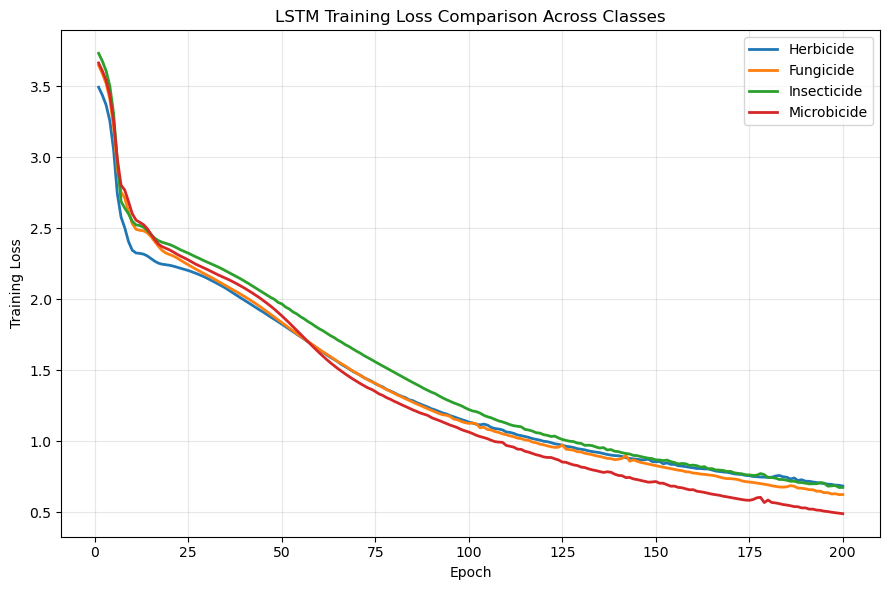

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all logs
herb = pd.read_csv("herb_training_log.csv")
fungi = pd.read_csv("fungi_training_log.csv")
insect = pd.read_csv("insect_training_log.csv")
micro = pd.read_csv("micro_training_log.csv")

plt.figure(figsize=(9,6))

plt.plot(herb['epoch'], herb['loss'], label="Herbicide", linewidth=2)
plt.plot(fungi['epoch'], fungi['loss'], label="Fungicide", linewidth=2)
plt.plot(insect['epoch'], insect['loss'], label="Insecticide", linewidth=2)
plt.plot(micro['epoch'], micro['loss'], label="Microbicide", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LSTM Training Loss Comparison Across Classes")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("LSTM_Loss_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [127]:
#To check the column names
import pandas as pd

df = pd.read_csv("insect_generated_raw_3000_reran.csv")
print(df.columns)
print(df.head())

Index(['generated_smiles'], dtype='object')
                                    generated_smiles
0                 CC(C1=CC=CC=C1C(C2=CC=C(C=C2)Cl)Cl
1  [O-]S(=S)(=O)[O-].[O-].(=ON)[O-].[S-]2.OC[C.]....
2                                 CN(C)C1=CC=CC=C1Cl
3  CC1(=CC(=C1(C(=O)OC)C2=CC(=CC(=CC2=S2)CC)CC=CC...
4                  CC(=CC6CC)CC=CN.C1=C3CC=CC(=C2)Cl


**Evaluation**

In [128]:
import pandas as pd
from rdkit import Chem

files = {
    "Herbicide": "herb_generated_raw_3000_rerun.csv",
    "Fungicide": "fungi_generated_raw_3000.csv",
    "Insecticide": "insect_generated_raw_3000_reran.csv",
    "Microbicide": "micro_generated_raw_3000_reran.csv"
}

for name, file in files.items():
    df = pd.read_csv(file)
    
    total_rows = len(df)
    missing = df["generated_smiles"].isna().sum()
    
    smiles_list = df["generated_smiles"].dropna().tolist()
    
    valid_molecules = []
    
    for sm in smiles_list:
        mol = Chem.MolFromSmiles(sm)
        if mol is not None:
            valid_molecules.append(Chem.MolToSmiles(mol))  # canonical form
    
    total_generated = len(smiles_list)
    valid_count = len(valid_molecules)
    unique_valid_count = len(set(valid_molecules))
    
    validity = (valid_count / total_generated) * 100
    uniqueness = (unique_valid_count / valid_count) * 100 if valid_count > 0 else 0
    
    print("\n==========", name, "==========")
    print("Total rows:", total_rows)
    print("Missing SMILES:", missing)
    print("Total Generated:", total_generated)
    print("Valid Molecules:", valid_count)
    print("Validity %:", round(validity, 2))
    print("Unique Valid Molecules:", unique_valid_count)
    print("Uniqueness %:", round(uniqueness, 2))


========== Herbicide ==========
Total rows: 3000
Missing SMILES: 1
Total Generated: 2999
Valid Molecules: 338
Validity %: 11.27
Unique Valid Molecules: 338
Uniqueness %: 100.0

========== Fungicide ==========
Total rows: 3000
Missing SMILES: 0
Total Generated: 3000
Valid Molecules: 806
Validity %: 26.87
Unique Valid Molecules: 727
Uniqueness %: 90.2

========== Insecticide ==========
Total rows: 3000
Missing SMILES: 1
Total Generated: 2999
Valid Molecules: 754
Validity %: 25.14
Unique Valid Molecules: 735
Uniqueness %: 97.48

========== Microbicide ==========
Total rows: 3000
Missing SMILES: 0
Total Generated: 3000
Valid Molecules: 920
Validity %: 30.67
Unique Valid Molecules: 771
Uniqueness %: 83.8


**Novelty**

In [129]:
import pandas as pd
from rdkit import Chem

files = {
    "Herbicide": {
        "generated": "herb_generated_raw_3000_rerun.csv",
        "train": "synthetic_herb_train_rerun.csv"
    },
    "Fungicide": {
        "generated": "fungi_generated_raw_3000.csv",
        "train": "synthetic_fungi_train_rerun.csv"
    },
    "Insecticide": {
        "generated": "insect_generated_raw_3000_reran.csv",
        "train": "synthetic_insect_train_reran.csv"
    },
    "Microbicide": {
        "generated": "micro_generated_raw_3000_reran.csv",
        "train": "synthetic_micro_train_reran.csv"
    }
}

for name, paths in files.items():
    
    # ---- Load training data ----
    train_df = pd.read_csv(paths["train"])
    
    train_smiles = set()
    for sm in train_df["Smile"].dropna():   # <-- corrected here
        mol = Chem.MolFromSmiles(sm)
        if mol is not None:
            train_smiles.add(Chem.MolToSmiles(mol))
    
    # ---- Load generated data ----
    gen_df = pd.read_csv(paths["generated"])
    gen_smiles = gen_df["generated_smiles"].dropna().tolist()
    
    valid_generated = set()
    for sm in gen_smiles:
        mol = Chem.MolFromSmiles(sm)
        if mol is not None:
            valid_generated.add(Chem.MolToSmiles(mol))
    
    # ---- Compute Novelty ----
    novel = valid_generated - train_smiles
    
    novelty = (len(novel) / len(valid_generated)) * 100 if len(valid_generated) > 0 else 0
    
    print("\n==========", name, "==========")
    print("Valid Generated:", len(valid_generated))
    print("Novel Molecules:", len(novel))
    print("Novelty %:", round(novelty, 2))


========== Herbicide ==========
Valid Generated: 338
Novel Molecules: 95
Novelty %: 28.11

========== Fungicide ==========
Valid Generated: 727
Novel Molecules: 663
Novelty %: 91.2

========== Insecticide ==========
Valid Generated: 735
Novel Molecules: 685
Novelty %: 93.2

========== Microbicide ==========
Valid Generated: 771
Novel Molecules: 593
Novelty %: 76.91


**Comparison evaluation of LSTM Generated compounds**

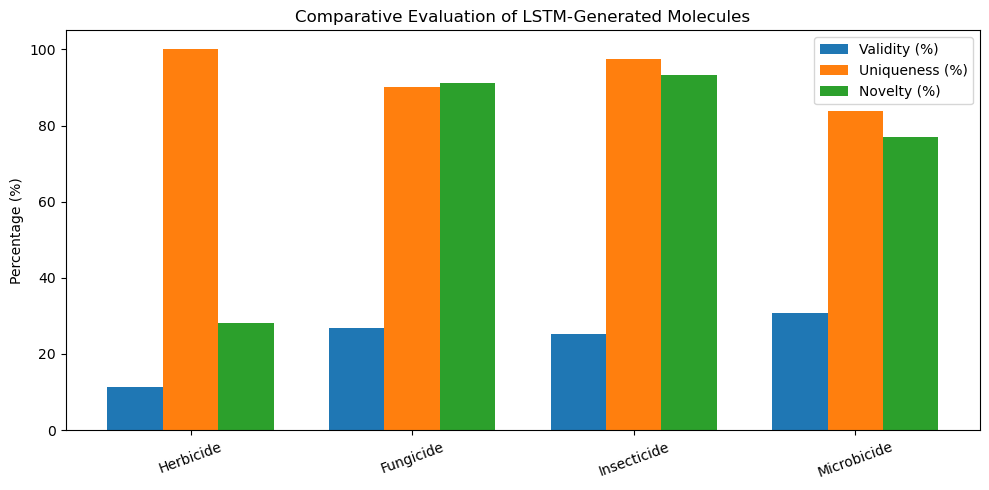

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Data
classes = ["Herbicide", "Fungicide", "Insecticide", "Microbicide"]

validity = [11.27, 26.87, 25.14, 30.67]
uniqueness = [100.0, 90.2, 97.48, 83.8]
novelty = [28.11, 91.2, 93.2, 76.91]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, validity, width, label="Validity (%)")
plt.bar(x, uniqueness, width, label="Uniqueness (%)")
plt.bar(x + width, novelty, width, label="Novelty (%)")

plt.xticks(x, classes, rotation=20)
plt.ylabel("Percentage (%)")
plt.title("Comparative Evaluation of LSTM-Generated Molecules")
plt.legend()

plt.tight_layout()
plt.savefig("Final_LSTM_Generation_Evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

**SMILES Length Distribution**

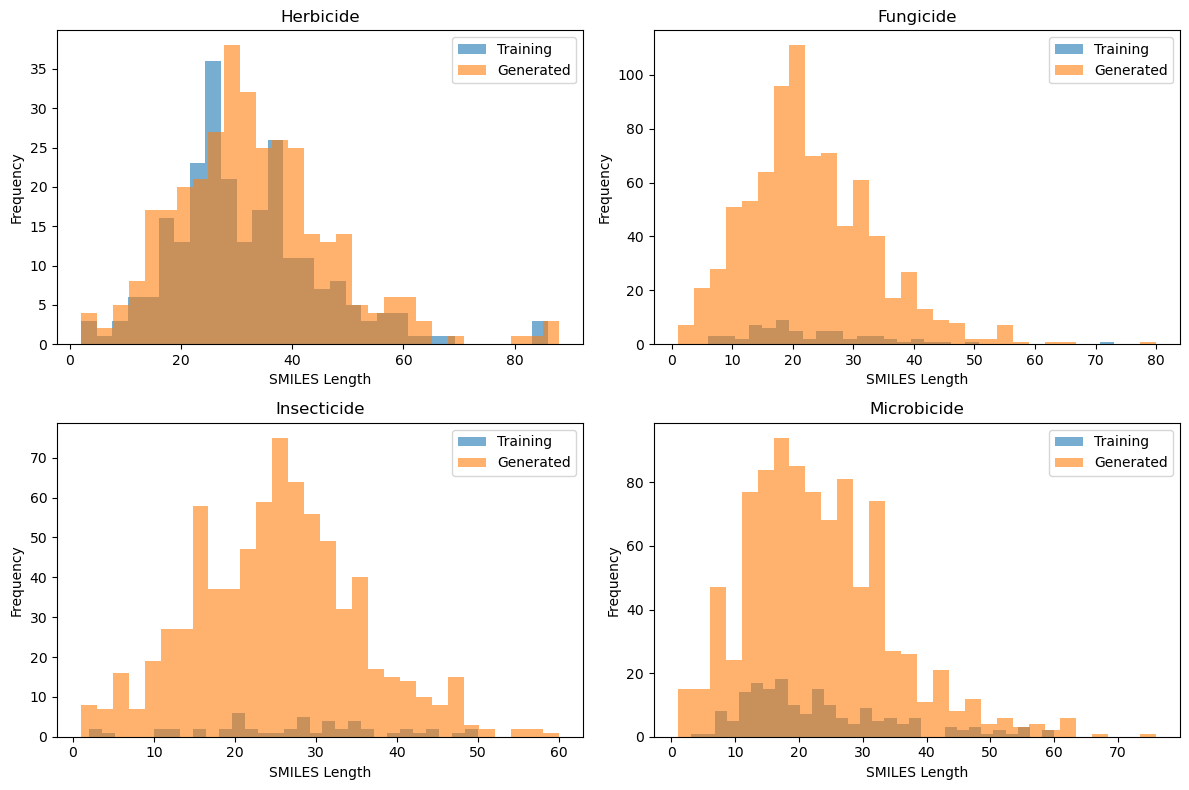

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem

files = {
    "Herbicide": {
        "train": "synthetic_herb_train_rerun.csv",
        "generated": "herb_generated_raw_3000_rerun.csv"
    },
    "Fungicide": {
        "train": "synthetic_fungi_train_rerun.csv",
        "generated": "fungi_generated_raw_3000.csv"
    },
    "Insecticide": {
        "train": "synthetic_insect_train_reran.csv",
        "generated": "insect_generated_raw_3000_reran.csv"
    },
    "Microbicide": {
        "train": "synthetic_micro_train_reran.csv",
        "generated": "micro_generated_raw_3000_reran.csv"
    }
}

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for ax, (name, paths) in zip(axes, files.items()):
    
    # Training data
    train_df = pd.read_csv(paths["train"])
    train_smiles = train_df["Smile"].dropna().tolist()
    
    # Generated data
    gen_df = pd.read_csv(paths["generated"])
    gen_smiles = gen_df["generated_smiles"].dropna().tolist()
    
    valid_generated = []
    for sm in gen_smiles:
        mol = Chem.MolFromSmiles(sm)
        if mol is not None:
            valid_generated.append(sm)
    
    # Length calculation
    train_lengths = [len(sm) for sm in train_smiles]
    gen_lengths = [len(sm) for sm in valid_generated]
    
    ax.hist(train_lengths, bins=30, alpha=0.6, label="Training")
    ax.hist(gen_lengths, bins=30, alpha=0.6, label="Generated")
    
    ax.set_title(name)
    ax.set_xlabel("SMILES Length")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig("All_Classes_SMILES_Length_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Molecular Weight Distribution (All Classes)**

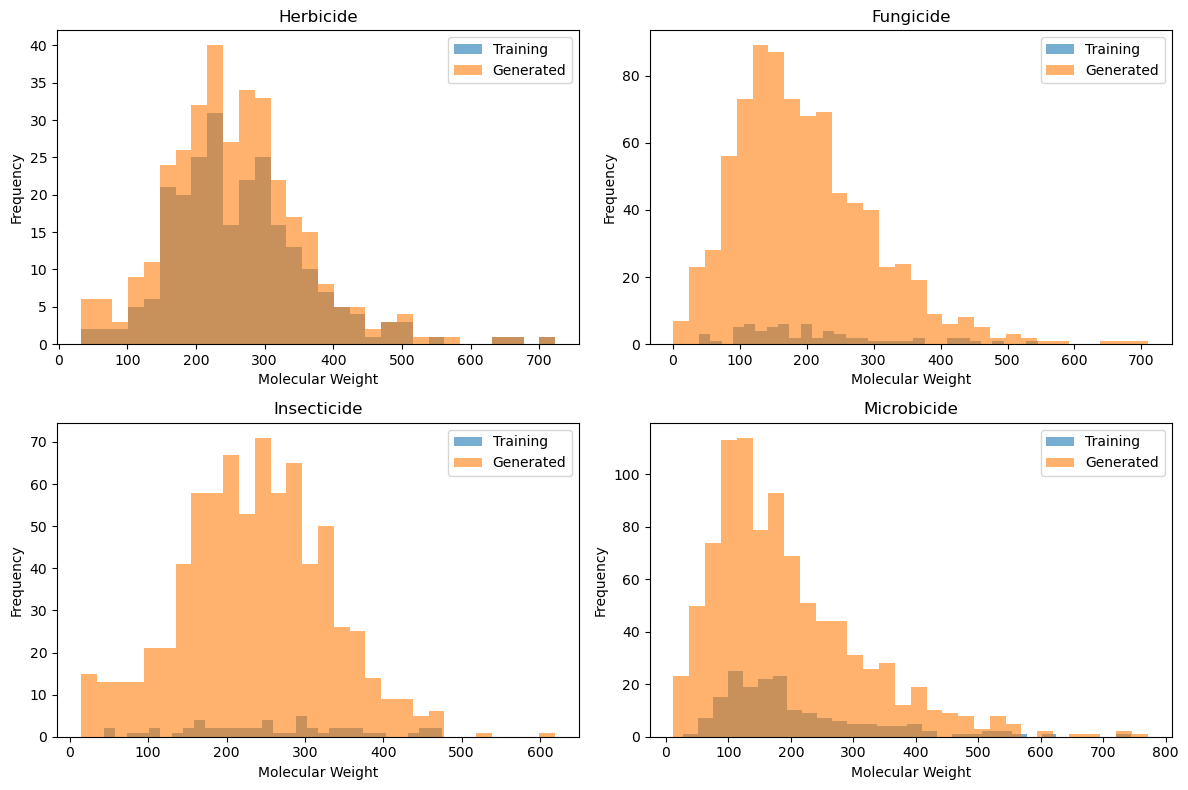

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

files = {
    "Herbicide": {
        "train": "synthetic_herb_train_rerun.csv",
        "generated": "herb_generated_raw_3000_rerun.csv"
    },
    "Fungicide": {
        "train": "synthetic_fungi_train_rerun.csv",
        "generated": "fungi_generated_raw_3000.csv"
    },
    "Insecticide": {
        "train": "synthetic_insect_train_reran.csv",
        "generated": "insect_generated_raw_3000_reran.csv"
    },
    "Microbicide": {
        "train": "synthetic_micro_train_reran.csv",
        "generated": "micro_generated_raw_3000_reran.csv"
    }
}

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for ax, (name, paths) in zip(axes, files.items()):
    
    # ---- Training ----
    train_df = pd.read_csv(paths["train"])
    train_smiles = train_df["Smile"].dropna().tolist()
    
    train_mw = []
    for sm in train_smiles:
        mol = Chem.MolFromSmiles(sm)
        if mol is not None:
            train_mw.append(Descriptors.MolWt(mol))
    
    # ---- Generated ----
    gen_df = pd.read_csv(paths["generated"])
    gen_smiles = gen_df["generated_smiles"].dropna().tolist()
    
    gen_mw = []
    for sm in gen_smiles:
        mol = Chem.MolFromSmiles(sm)
        if mol is not None:
            gen_mw.append(Descriptors.MolWt(mol))
    
    # ---- Plot ----
    ax.hist(train_mw, bins=30, alpha=0.6, label="Training")
    ax.hist(gen_mw, bins=30, alpha=0.6, label="Generated")
    
    ax.set_title(name)
    ax.set_xlabel("Molecular Weight")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig("All_Classes_MW_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()